<div style="text-align: center;">

# -------------------------------------------------

</div>

<div style="text-align: center;">

### **Details of Data Analyst**  

</div>

**Name:** Ayushman Behera  
**Registration Number:** 12301257  
**Roll Number:** 39  
**Section:** K23UP  
**Group:** 2  

<div style="text-align: center;">

# -------------------------------------------------

</div>

<div style="text-align: center;">

# **Road Accident Analysis in India**

### **Exploratory Data Analysis, Visualization & Statistical Inference Report**

</div>

### **1. Introduction & Problem Context**

**Road accidents** remain one of the leading causes of fatalities and injuries in India. Understanding the factors contributing to accidents—such as speed, road type, lighting conditions, alcohol involvement, and vehicle density—is crucial for designing effective road safety policies. This project aims to perform a comprehensive exploratory data analysis and statistical investigation on a large-scale Indian road accident dataset to uncover meaningful patterns, trends, and relationships within the data.

The analysis follows a structured data science approach beginning from data loading and cleaning, followed by visualization-based exploration and finally inferential statistical testing to support data-driven conclusions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **2. Dataset Overview and Structure**

The dataset contains **22,500** accident records with **18** attributes, representing accident identifiers, temporal information, geographical details, road and environmental conditions, speed-related metrics, injury severity, and economic damage.  

**Key observations from the dataset structure:**  
* Both categorical (state, city, road type, weather, light condition) and numerical variables (speed, casualties, injuries, damage cost) are present.  
* This mixed data type structure allows for univariate, bivariate, and multivariate analysis.
The dataset size is sufficiently large to apply statistical inference techniques reliably.  

**Functions used:**  
* **pd.read_csv()** to load structured data  
* **df.info()** and **df.describe()** to understand schema, data types, and statistical summaries  

These functions are essential for initial data familiarity and validation.

In [3]:
df = pd.read_csv("indian_road_accidents.csv")
df.head()

,accident_id,date,time,state,city,road_type,weather,light_condition,speed_limit_kmph,avg_speed_est_kmph,vehicles_involved,casualties_total,fatalities,serious_injuries,minor_injuries,alcohol_involved,hit_and_run,damage_cost_inr
0,ACC2020051000000,2020-05-10,10:42,West Bengal,Kolkata,Urban Road,Clear,Daylight,40,21.5,2,0,0,0,0,0.0,1.0,29578.40
1,ACC2023081000001,2023-08-10,10:46,Gujarat,Vadodara,Urban Road,Clear,Dawn/Dusk,50,48.8,1,1,0,0,1,0.0,0.0,68289.65
2,ACC2023051000002,2023-05-10,17:39,Karnataka,Mysuru,Urban Road,Clear,Daylight,50,NaN,2,2,0,0,2,0.0,0.0,22122.37
3,ACC2025011200003,2025-01-12,21:00,Karnataka,Bengaluru,National Highway,Clear,Night (unlit),90,95.5,1,1,0,0,1,0.0,0.0,64685.26
4,ACC2020081800004,2020-08-18,10:36,Chhattisgarh,Raipur,Expressway,Fog,Daylight,100,78.9,1,3,0,1,2,0.0,0.0,55014.18


In [4]:
df.shape

(22500, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22500 entries, 0 to 22499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   accident_id         22500 non-null  object 
 1   date                22500 non-null  object 
 2   time                22500 non-null  object 
 3   state               22500 non-null  object 
 4   city                22500 non-null  object 
 5   road_type           22500 non-null  object 
 6   weather             20700 non-null  object 
 7   light_condition     21375 non-null  object 
 8   speed_limit_kmph    22500 non-null  int64  
 9   avg_speed_est_kmph  21150 non-null  float64
 10  vehicles_involved   22500 non-null  int64  
 11  casualties_total    22500 non-null  int64  
 12  fatalities          22500 non-null  int64  
 13  serious_injuries    22500 non-null  int64  
 14  minor_injuries      22500 non-null  int64  
 15  alcohol_involved    22050 non-null  float64
 16  hit_

In [6]:
df.describe()

,speed_limit_kmph,avg_speed_est_kmph,vehicles_involved,casualties_total,fatalities,serious_injuries,minor_injuries,alcohol_involved,hit_and_run,damage_cost_inr
count,22500.000000,21150.000000,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000,22050.000000,22050.000000,2.160000e+04
mean,67.846667,61.518137,1.731200,2.780044,0.138800,0.877156,1.764089,0.090612,0.054785,8.716039e+04
std,19.395013,23.632254,1.231364,2.577795,0.611588,1.071647,1.798753,0.287063,0.227564,1.095256e+06
min,40.000000,14.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.360840e+03
25%,50.000000,44.500000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.965297e+04
50%,60.000000,57.400000,1.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4.855754e+04
75%,80.000000,75.500000,2.000000,4.000000,0.000000,1.000000,2.000000,0.000000,0.000000,7.916171e+04
max,120.000000,295.401231,12.000000,42.000000,17.000000,14.000000,28.000000,1.000000,1.000000,1.423843e+08


In [7]:
df.dtypes

accident_id            object
date                   object
time                   object
state                  object
city                   object
road_type              object
weather                object
light_condition        object
speed_limit_kmph        int64
avg_speed_est_kmph    float64
vehicles_involved       int64
casualties_total        int64
fatalities              int64
serious_injuries        int64
minor_injuries          int64
alcohol_involved      float64
hit_and_run           float64
damage_cost_inr       float64
dtype: object

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **3. Data Quality Assessment**

**Duplicate Records**  
The dataset was checked for duplicate rows using the **duplicated()** function. No duplicate records were found, confirming data uniqueness at the record level.  

**Why this matters:**  
Duplicate entries can bias statistical results, especially frequency-based analyses such as count plots and probability distributions.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Missing Value Analysis**  
Several columns such as weather, light_condition, avg_speed_est_kmph, alcohol_involved, and damage_cost_inr contained missing values.  

**Approach used:**  
* **Numerical columns** → Mean imputation using **fillna(df[col].mean())**  
* **Categorical columns** → Mode imputation using **fillna(df[col].mode()[0])**  

**Why this approach:**  
* **Mean** imputation preserves the overall distribution for continuous variables.  
* **Mode** imputation retains the most frequently occurring category, suitable for nominal data.  

This approach avoids excessive row deletion, which could reduce dataset representativeness. After imputation, the dataset contained zero missing values, making it suitable for downstream analysis.

In [10]:
df.isnull().sum()

accident_id              0
date                     0
time                     0
state                    0
city                     0
road_type                0
weather               1800
light_condition       1125
speed_limit_kmph         0
avg_speed_est_kmph    1350
vehicles_involved        0
casualties_total         0
fatalities               0
serious_injuries         0
minor_injuries           0
alcohol_involved       450
hit_and_run            450
damage_cost_inr        900
dtype: int64

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

In [46]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.isnull().sum()

accident_id           0
date                  0
time                  0
state                 0
city                  0
road_type             0
weather               0
light_condition       0
speed_limit_kmph      0
avg_speed_est_kmph    0
vehicles_involved     0
casualties_total      0
fatalities            0
serious_injuries      0
minor_injuries        0
alcohol_involved      0
hit_and_run           0
damage_cost_inr       0
dtype: int64

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **4. Outlier Detection and Treatment**

**Detection**  
Boxplots were generated for all numerical variables using **sns.boxplot().**  

**Why boxplots:**  
* They visually highlight extreme values using the **interquartile range (IQR).**
* They are especially effective for skewed distributions such as accident costs or injury counts.

**Observations:**
* Variables like avg_speed_est_kmph, casualties_total, damage_cost_inr showed significant outliers.
* These outliers represent rare but extreme accident events.

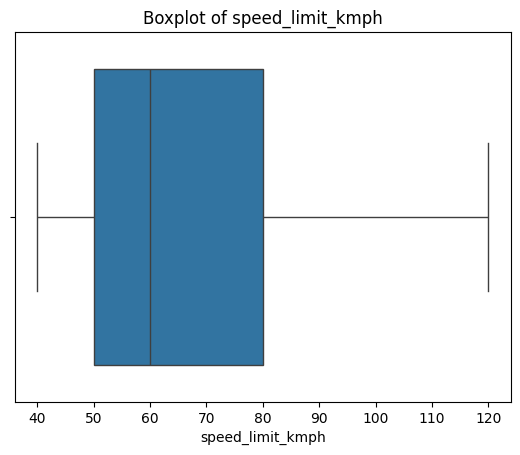

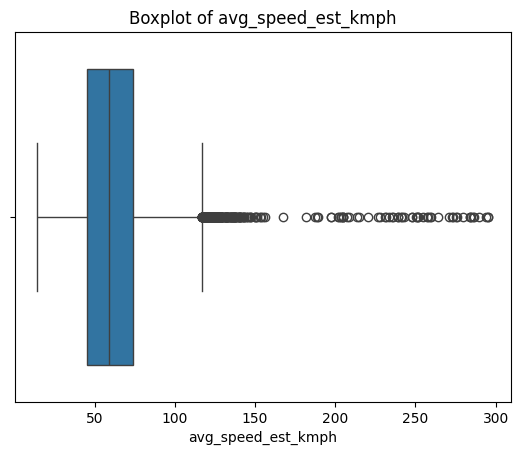

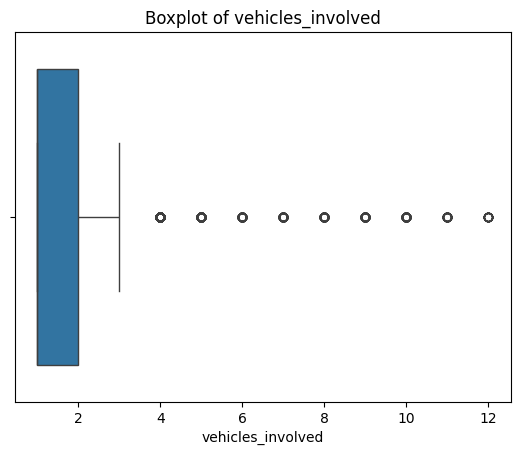

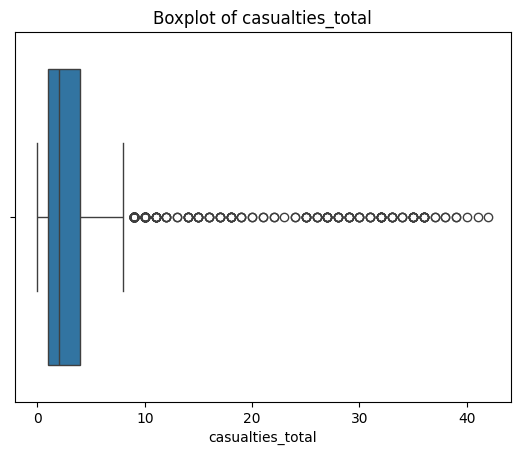

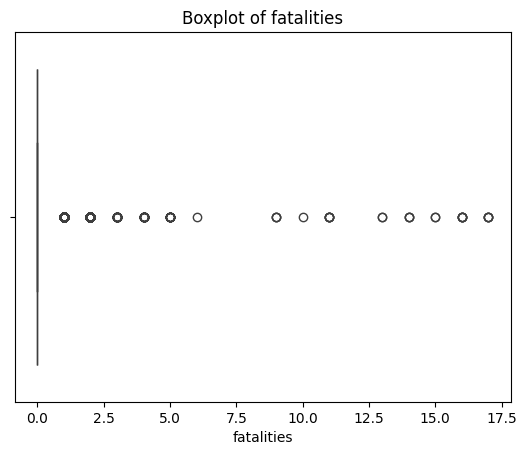

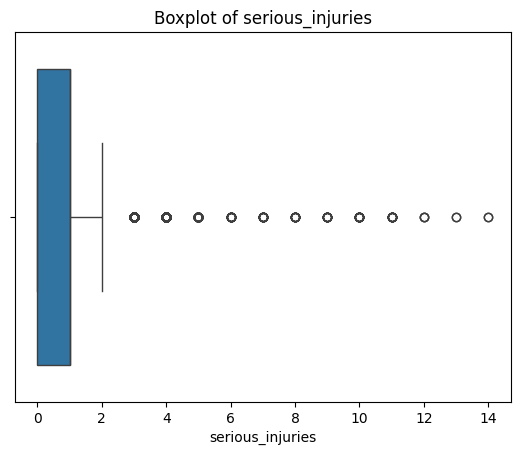

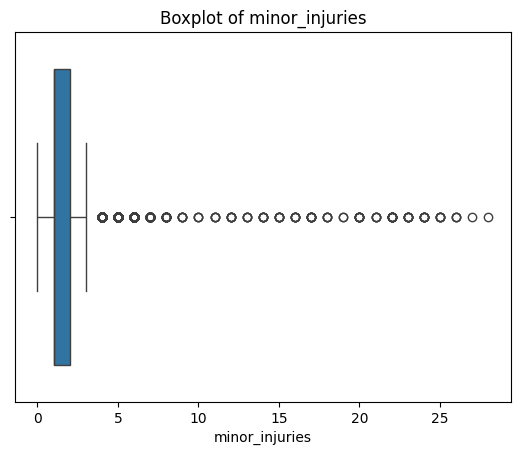

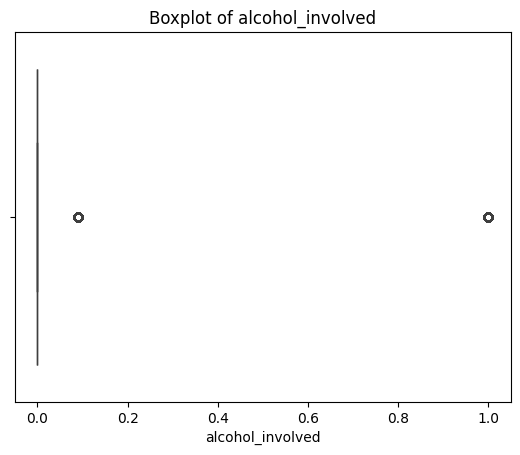

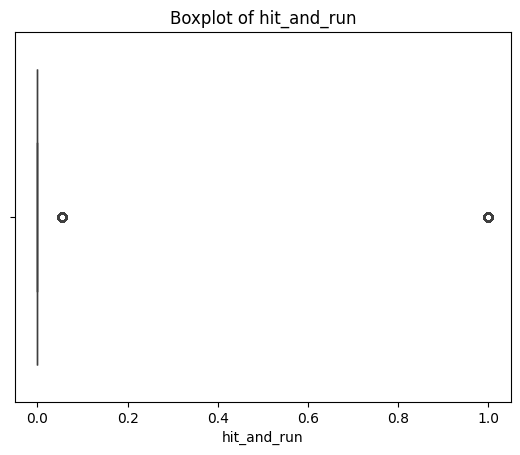

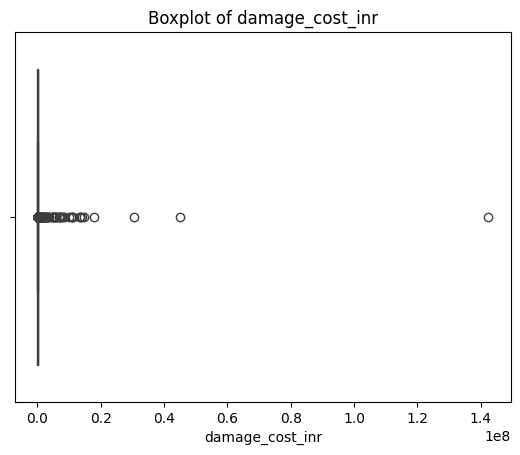

In [14]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Treatment**  

**The IQR capping method was applied:**  
Values below **Q1 − 1.5×IQR** and above **Q3 + 1.5×IQR** were capped.  

**Why capping instead of removal:**
* Removing extreme accidents would discard critical real-world events.
* Capping limits their influence without eliminating them, preserving analytical realism.

In [15]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

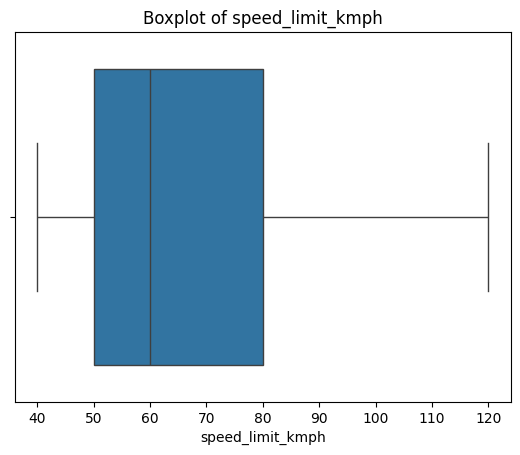

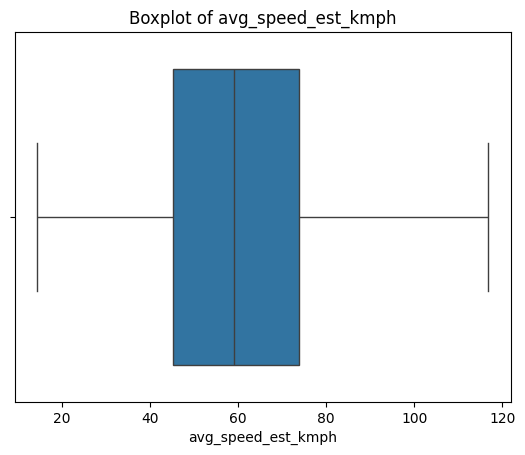

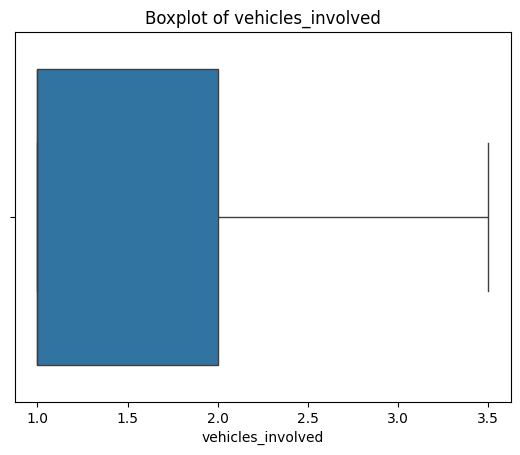

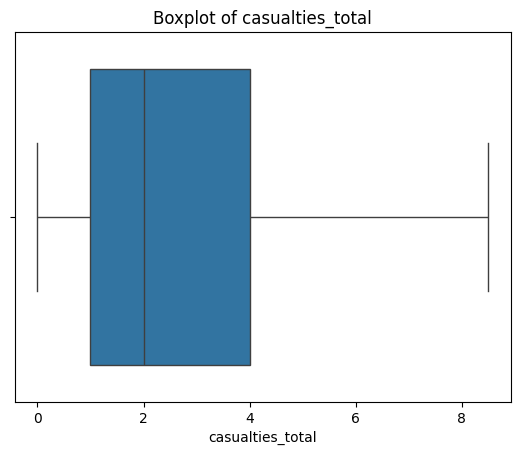

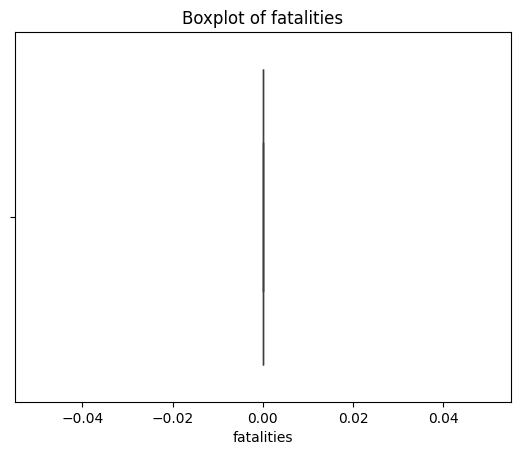

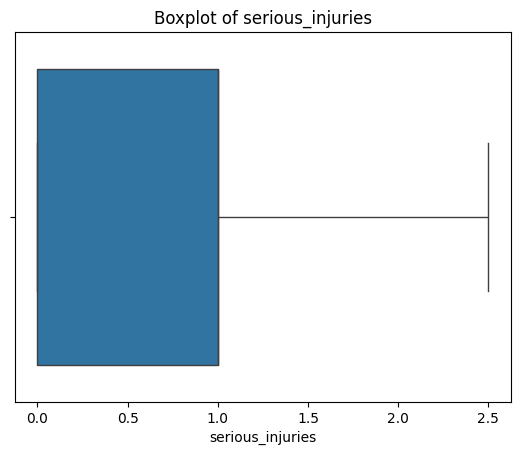

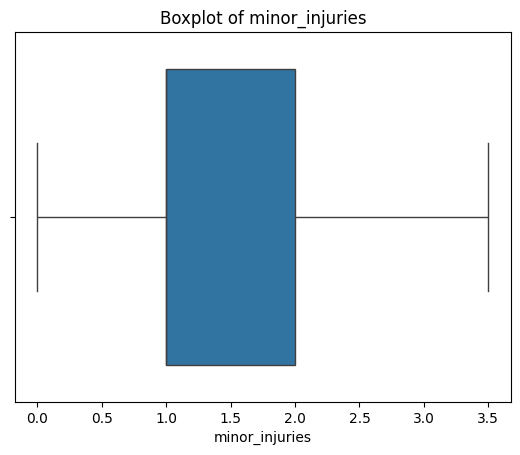

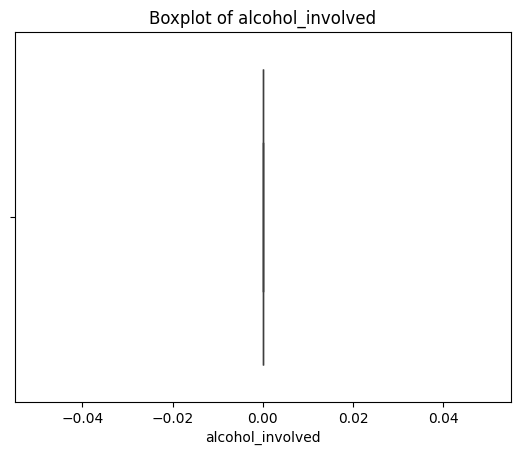

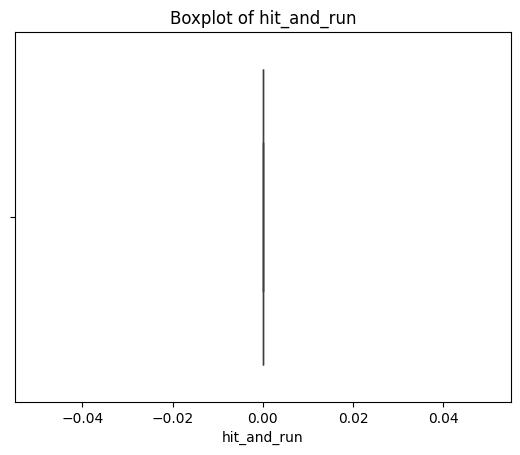

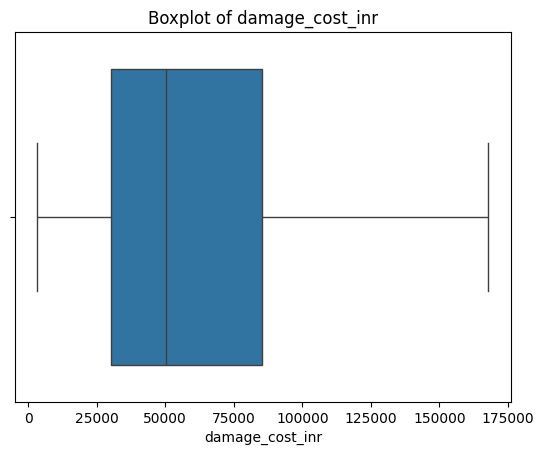

In [16]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **5. Data Standardization**

All numerical features were standardized using **StandardScaler.**

**Why standardization was necessary:**
* Variables are measured on different scales (speed in km/h, cost in INR, injury counts).
* Standardization ensures fair comparison and improves visualization symmetry.
* It is essential before correlation analysis and statistical modeling.

In [17]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **6. Univariate Analysis and Insights**

**Histograms**  
Histograms were plotted for each numerical variable using **plt.hist().**

**Insights:**
* Speed-related variables show multimodal distributions, reflecting different road types.
* Casualty and injury variables are right-skewed, indicating many minor accidents and few severe ones.
* Damage cost shows a heavy-tailed distribution, implying rare but extremely costly accidents.

**Why histograms:**
* They reveal distribution shape, skewness, and spread.
* Ideal for identifying non-normality.

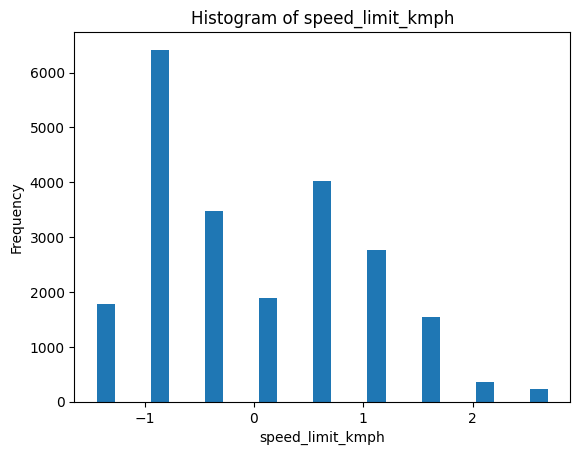

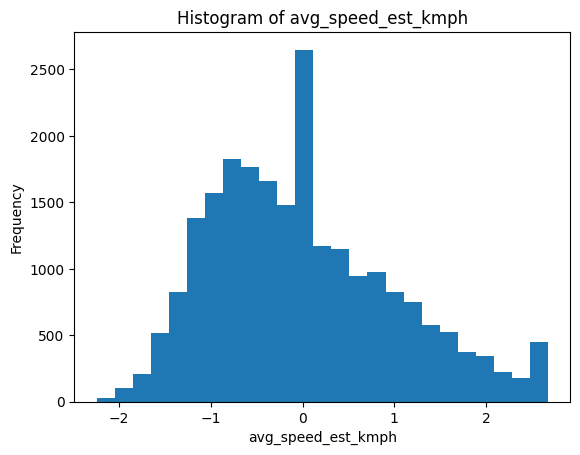

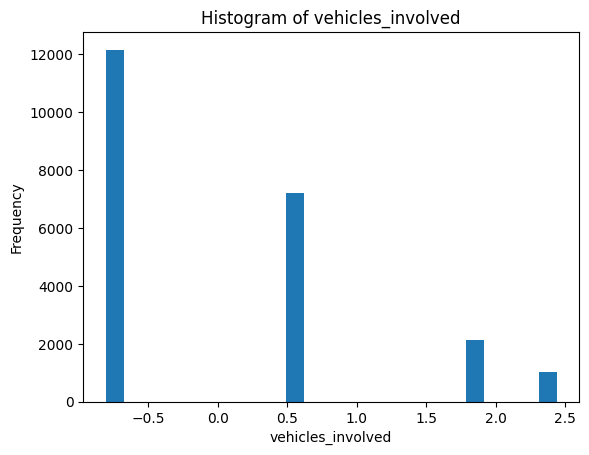

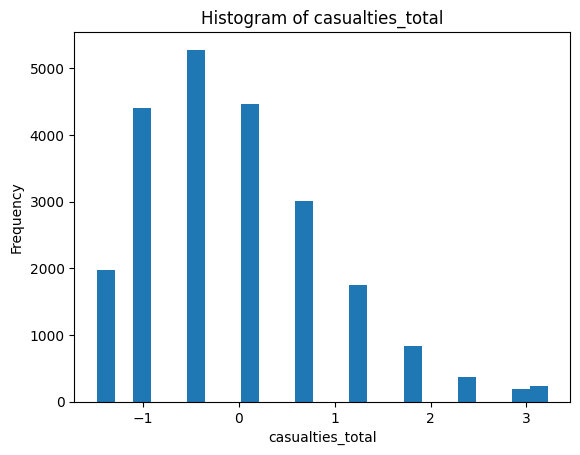

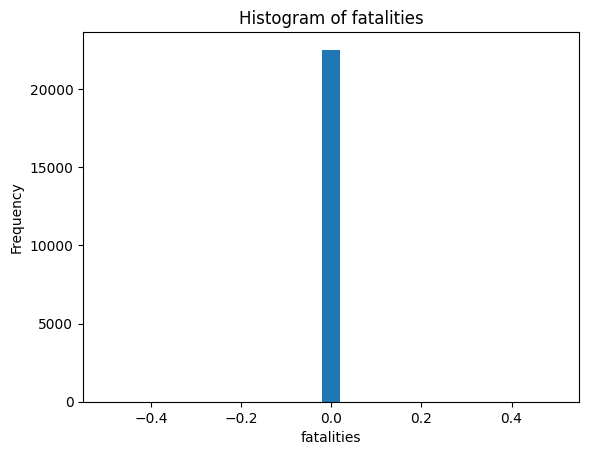

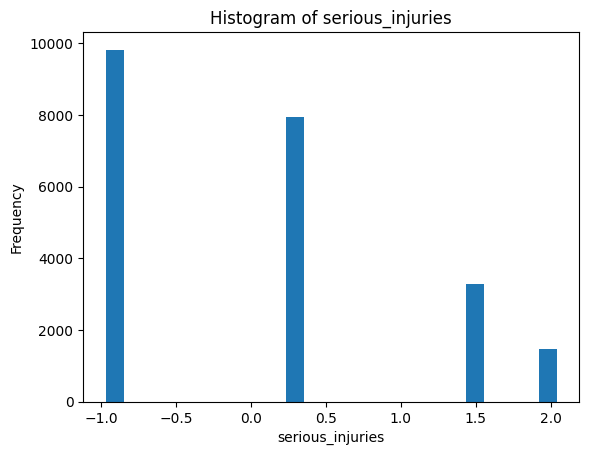

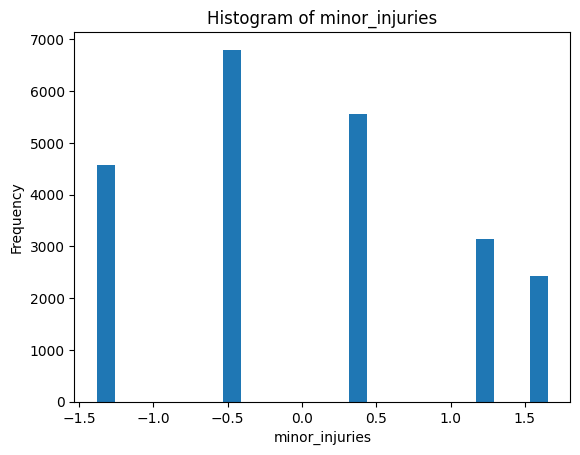

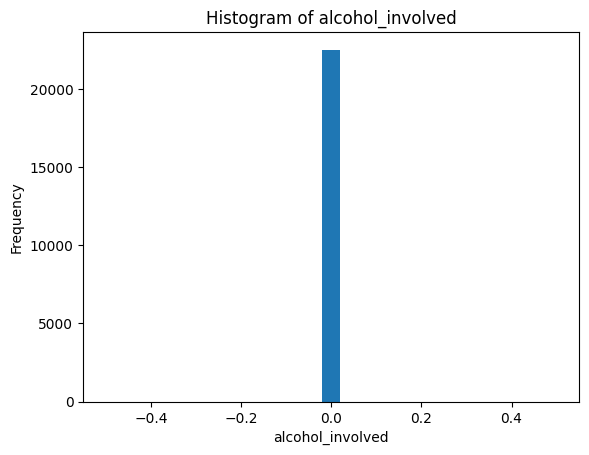

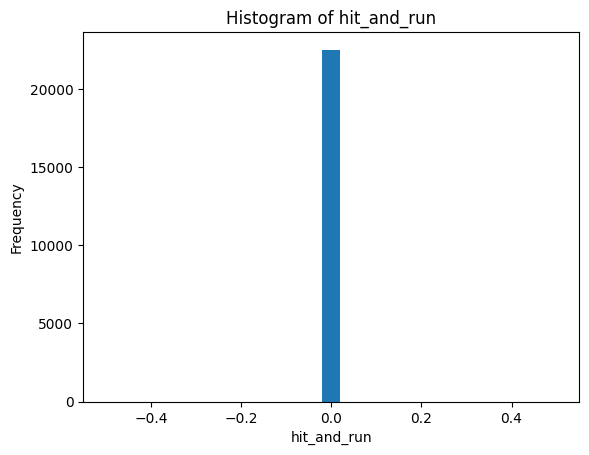

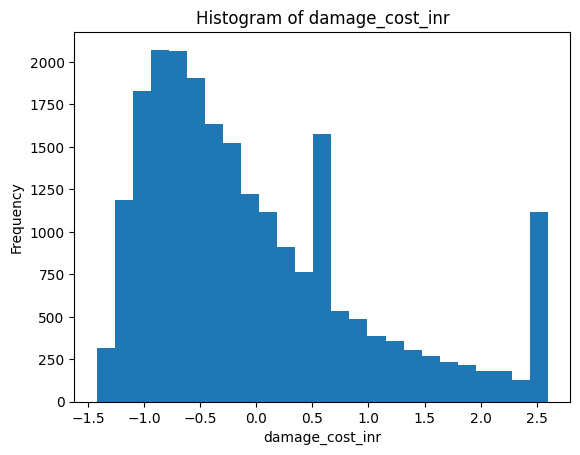

In [18]:
for col in num_cols:
    plt.hist(df[col], bins=25)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

**KDE Plots**  
Kernel Density Estimation plots were created using **sns.kdeplot().**

**Why KDE:**
* KDE provides a smooth estimate of the probability density function.
* Useful when histograms appear noisy.

**Insights:**
* Speed and casualty distributions show multiple density peaks, suggesting heterogeneous accident scenarios.
* Damage cost KDE confirms strong positive skewness.

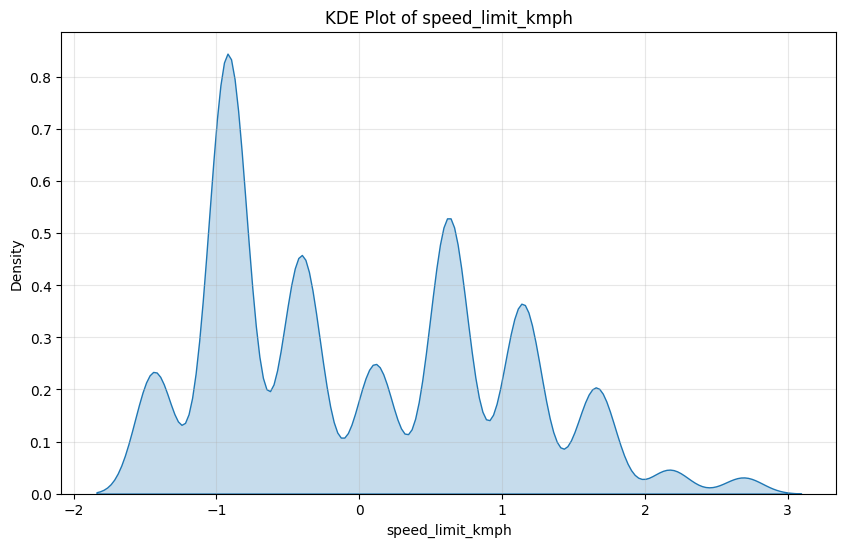

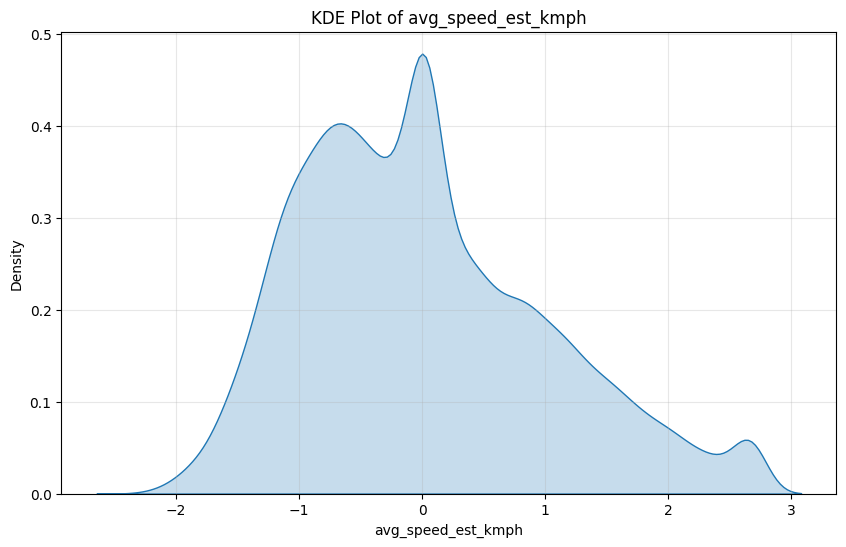

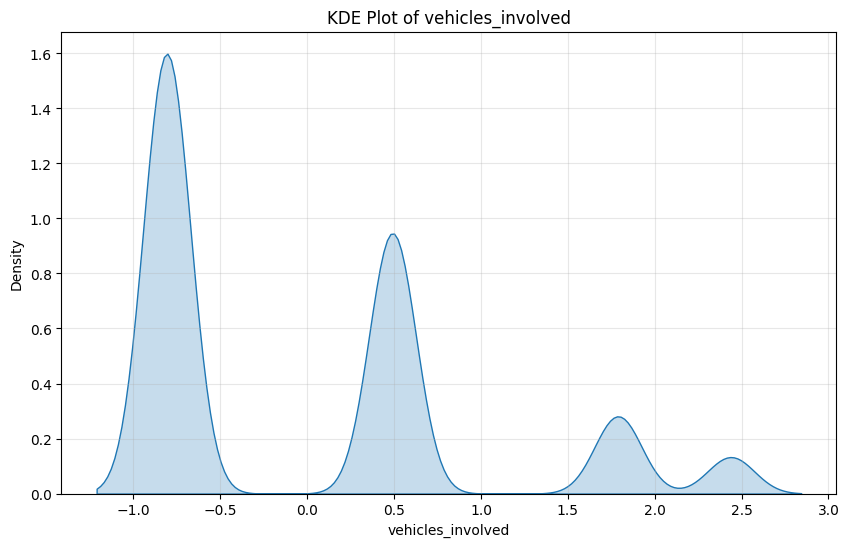

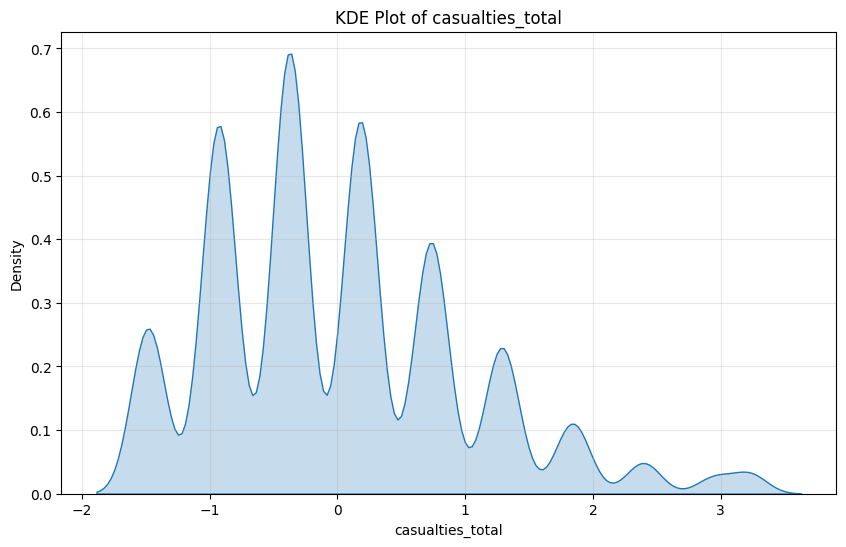

Skipping fatalities: No variance (all values are the same)


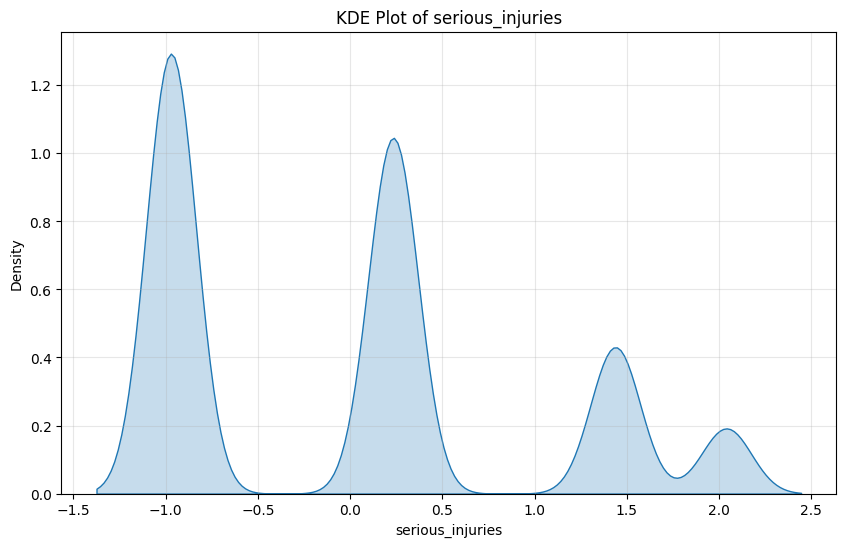

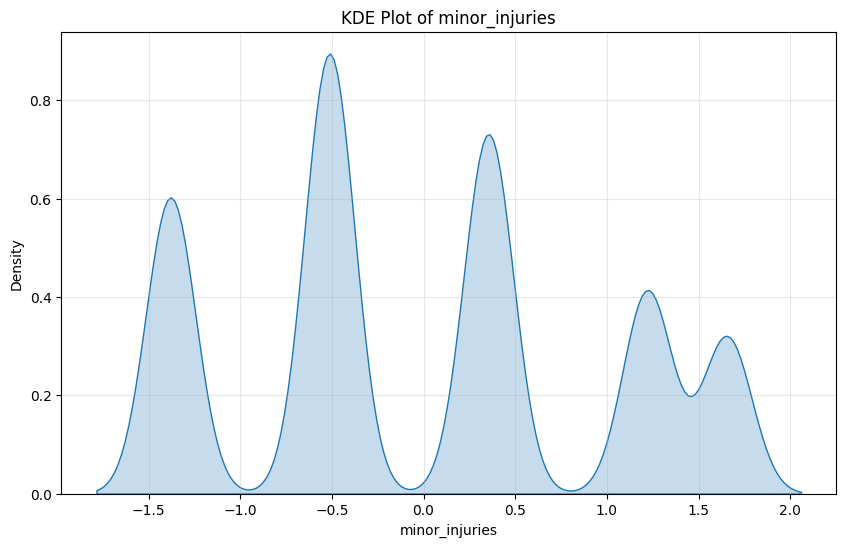

Skipping alcohol_involved: No variance (all values are the same)
Skipping hit_and_run: No variance (all values are the same)


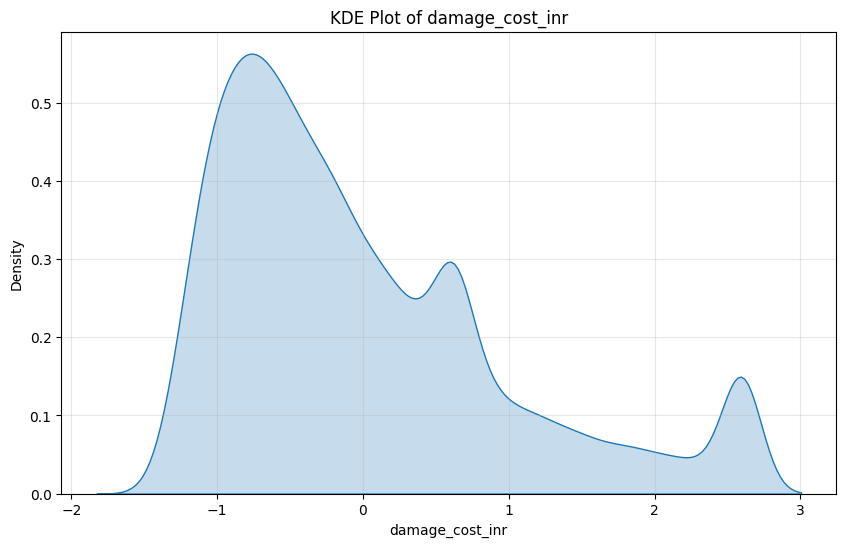

In [47]:
for col in num_cols:
    if df[col].nunique() > 1 and df[col].std() > 0:
        plt.figure(figsize=(10, 6))
        sns.kdeplot(df[col], fill=True, warn_singular=False)
        plt.title(f"KDE Plot of {col}")
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print(f"Skipping {col}: No variance (all values are the same)")

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Violin Plots**  
Violin plots were used for selected numerical columns.

**Why violin plots:**
* Combine boxplot summary with full distribution shape.
* Effective for understanding density concentration.

**Insights:**
* Injury-related variables show dense lower ranges with long upper tails.
* Indicates most accidents cause few injuries, but some result in severe harm.

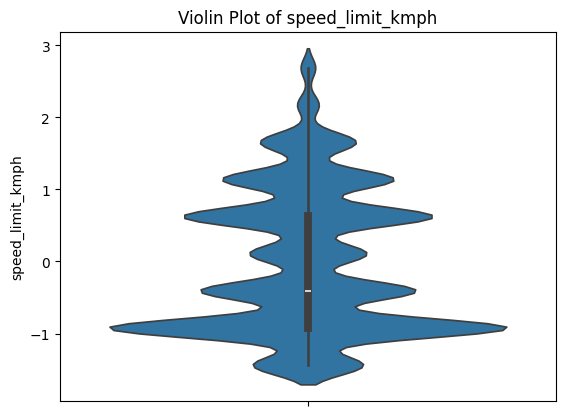

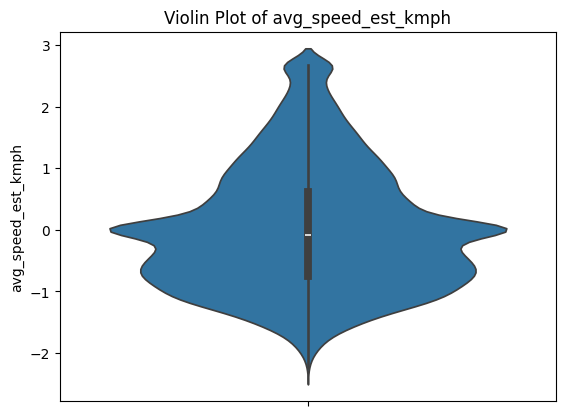

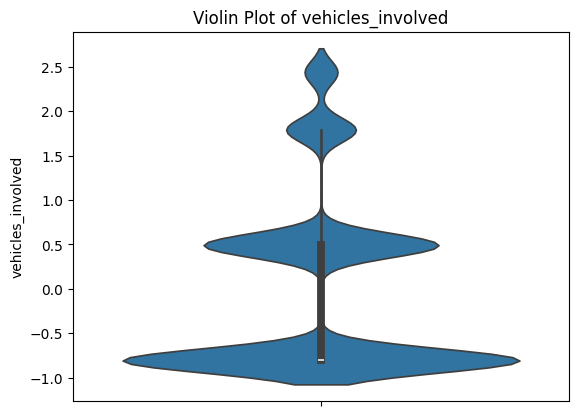

In [20]:
for col in num_cols[:3]:
    sns.violinplot(y=df[col])
    plt.title(f"Violin Plot of {col}")
    plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **8. Bivariate Analysis**

**Scatter Plots**  
Scatter plots were plotted between numerical pairs using **sns.scatterplot().**

**Insights:**
* Higher estimated speeds are weakly associated with higher casualties.
* Vehicle count correlates positively with total injuries.

**Why scatter plots:**
* Ideal for detecting linear or non-linear relationships.
* Helps identify clusters and trends.

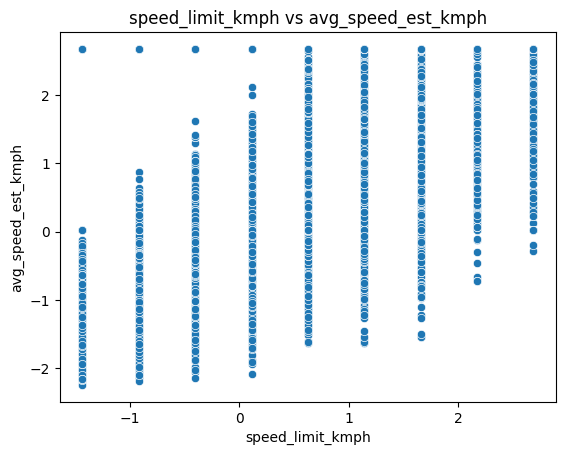

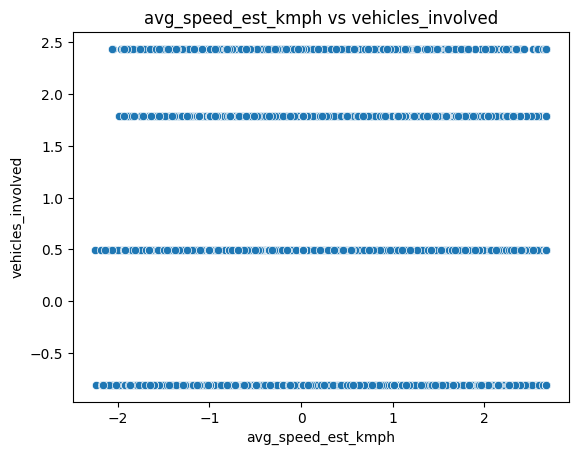

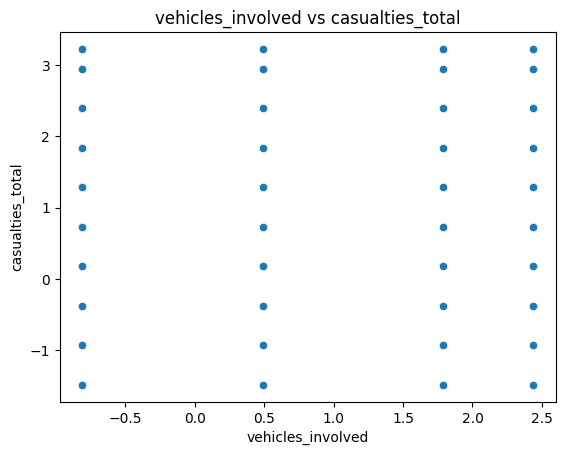

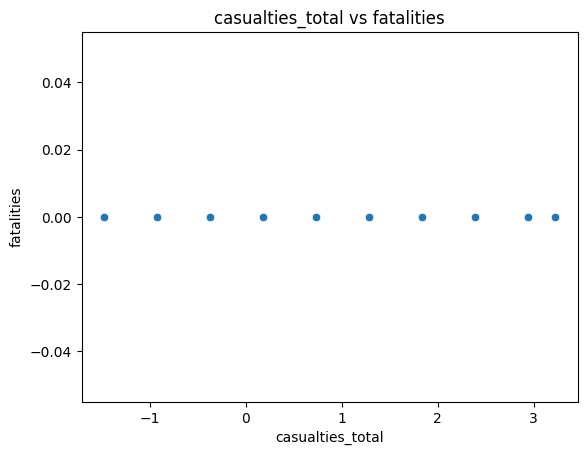

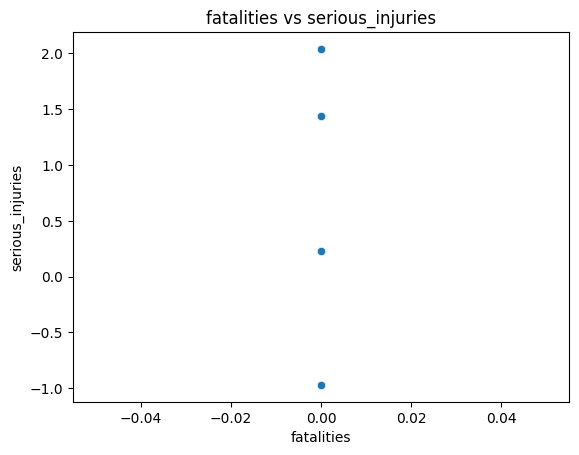

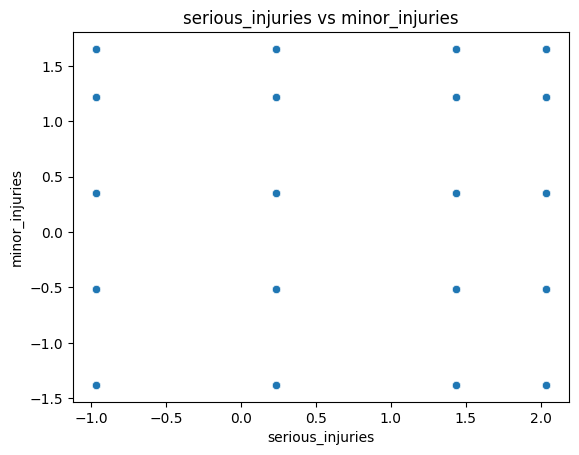

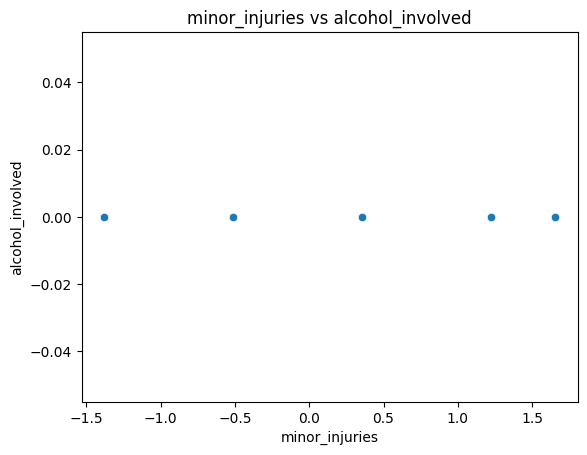

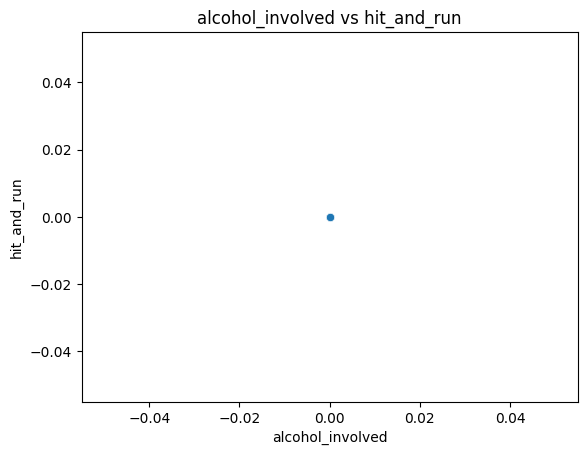

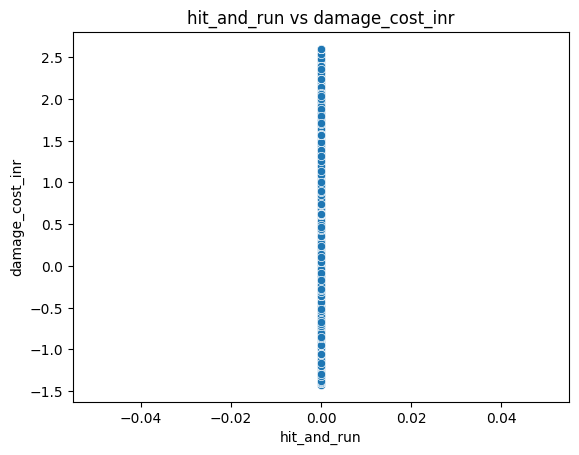

In [21]:
for i in range(len(num_cols)-1):
    sns.scatterplot(
        x=df[num_cols[i]],
        y=df[num_cols[i+1]]
    )
    plt.title(f"{num_cols[i]} vs {num_cols[i+1]}")
    plt.show()


<div style="text-align: center;">

# -------------------------------------------------

</div>

**Numerical vs Categorical (Boxplots)**   
Boxplots comparing numerical variables across categories (e.g., road type) were created.

**Insights:**
* National highways show higher speed variability.
* Urban roads show lower speed but higher accident density.

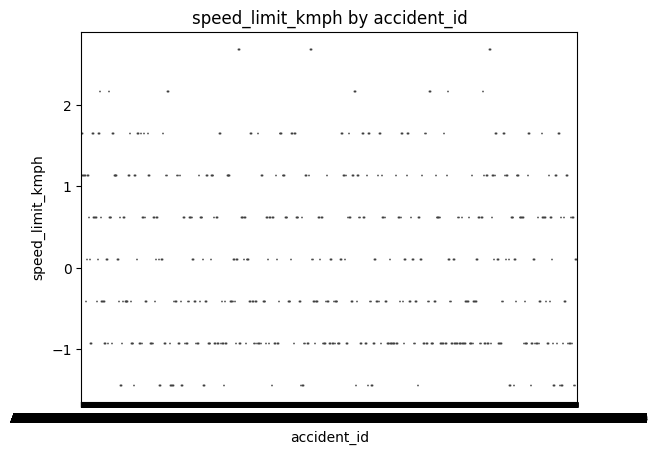

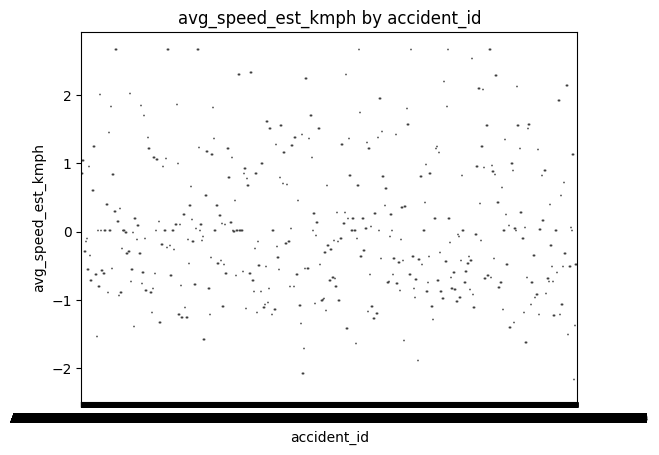

In [22]:
if len(cat_cols) > 0:
    for col in num_cols[:2]:
        sns.boxplot(
            x=df[cat_cols[0]],
            y=df[col]
        )
        plt.title(f"{col} by {cat_cols[0]}")
        plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **9. Multivariate Analysis**

**Pair Plot**  
A pair plot was created for all numerical variables.

**Why pair plot:**
* Provides a compact overview of pairwise relationships.
* Helps identify correlated variable pairs visually.

**Insight:**
* Casualties, injuries, and fatalities form a correlated group.

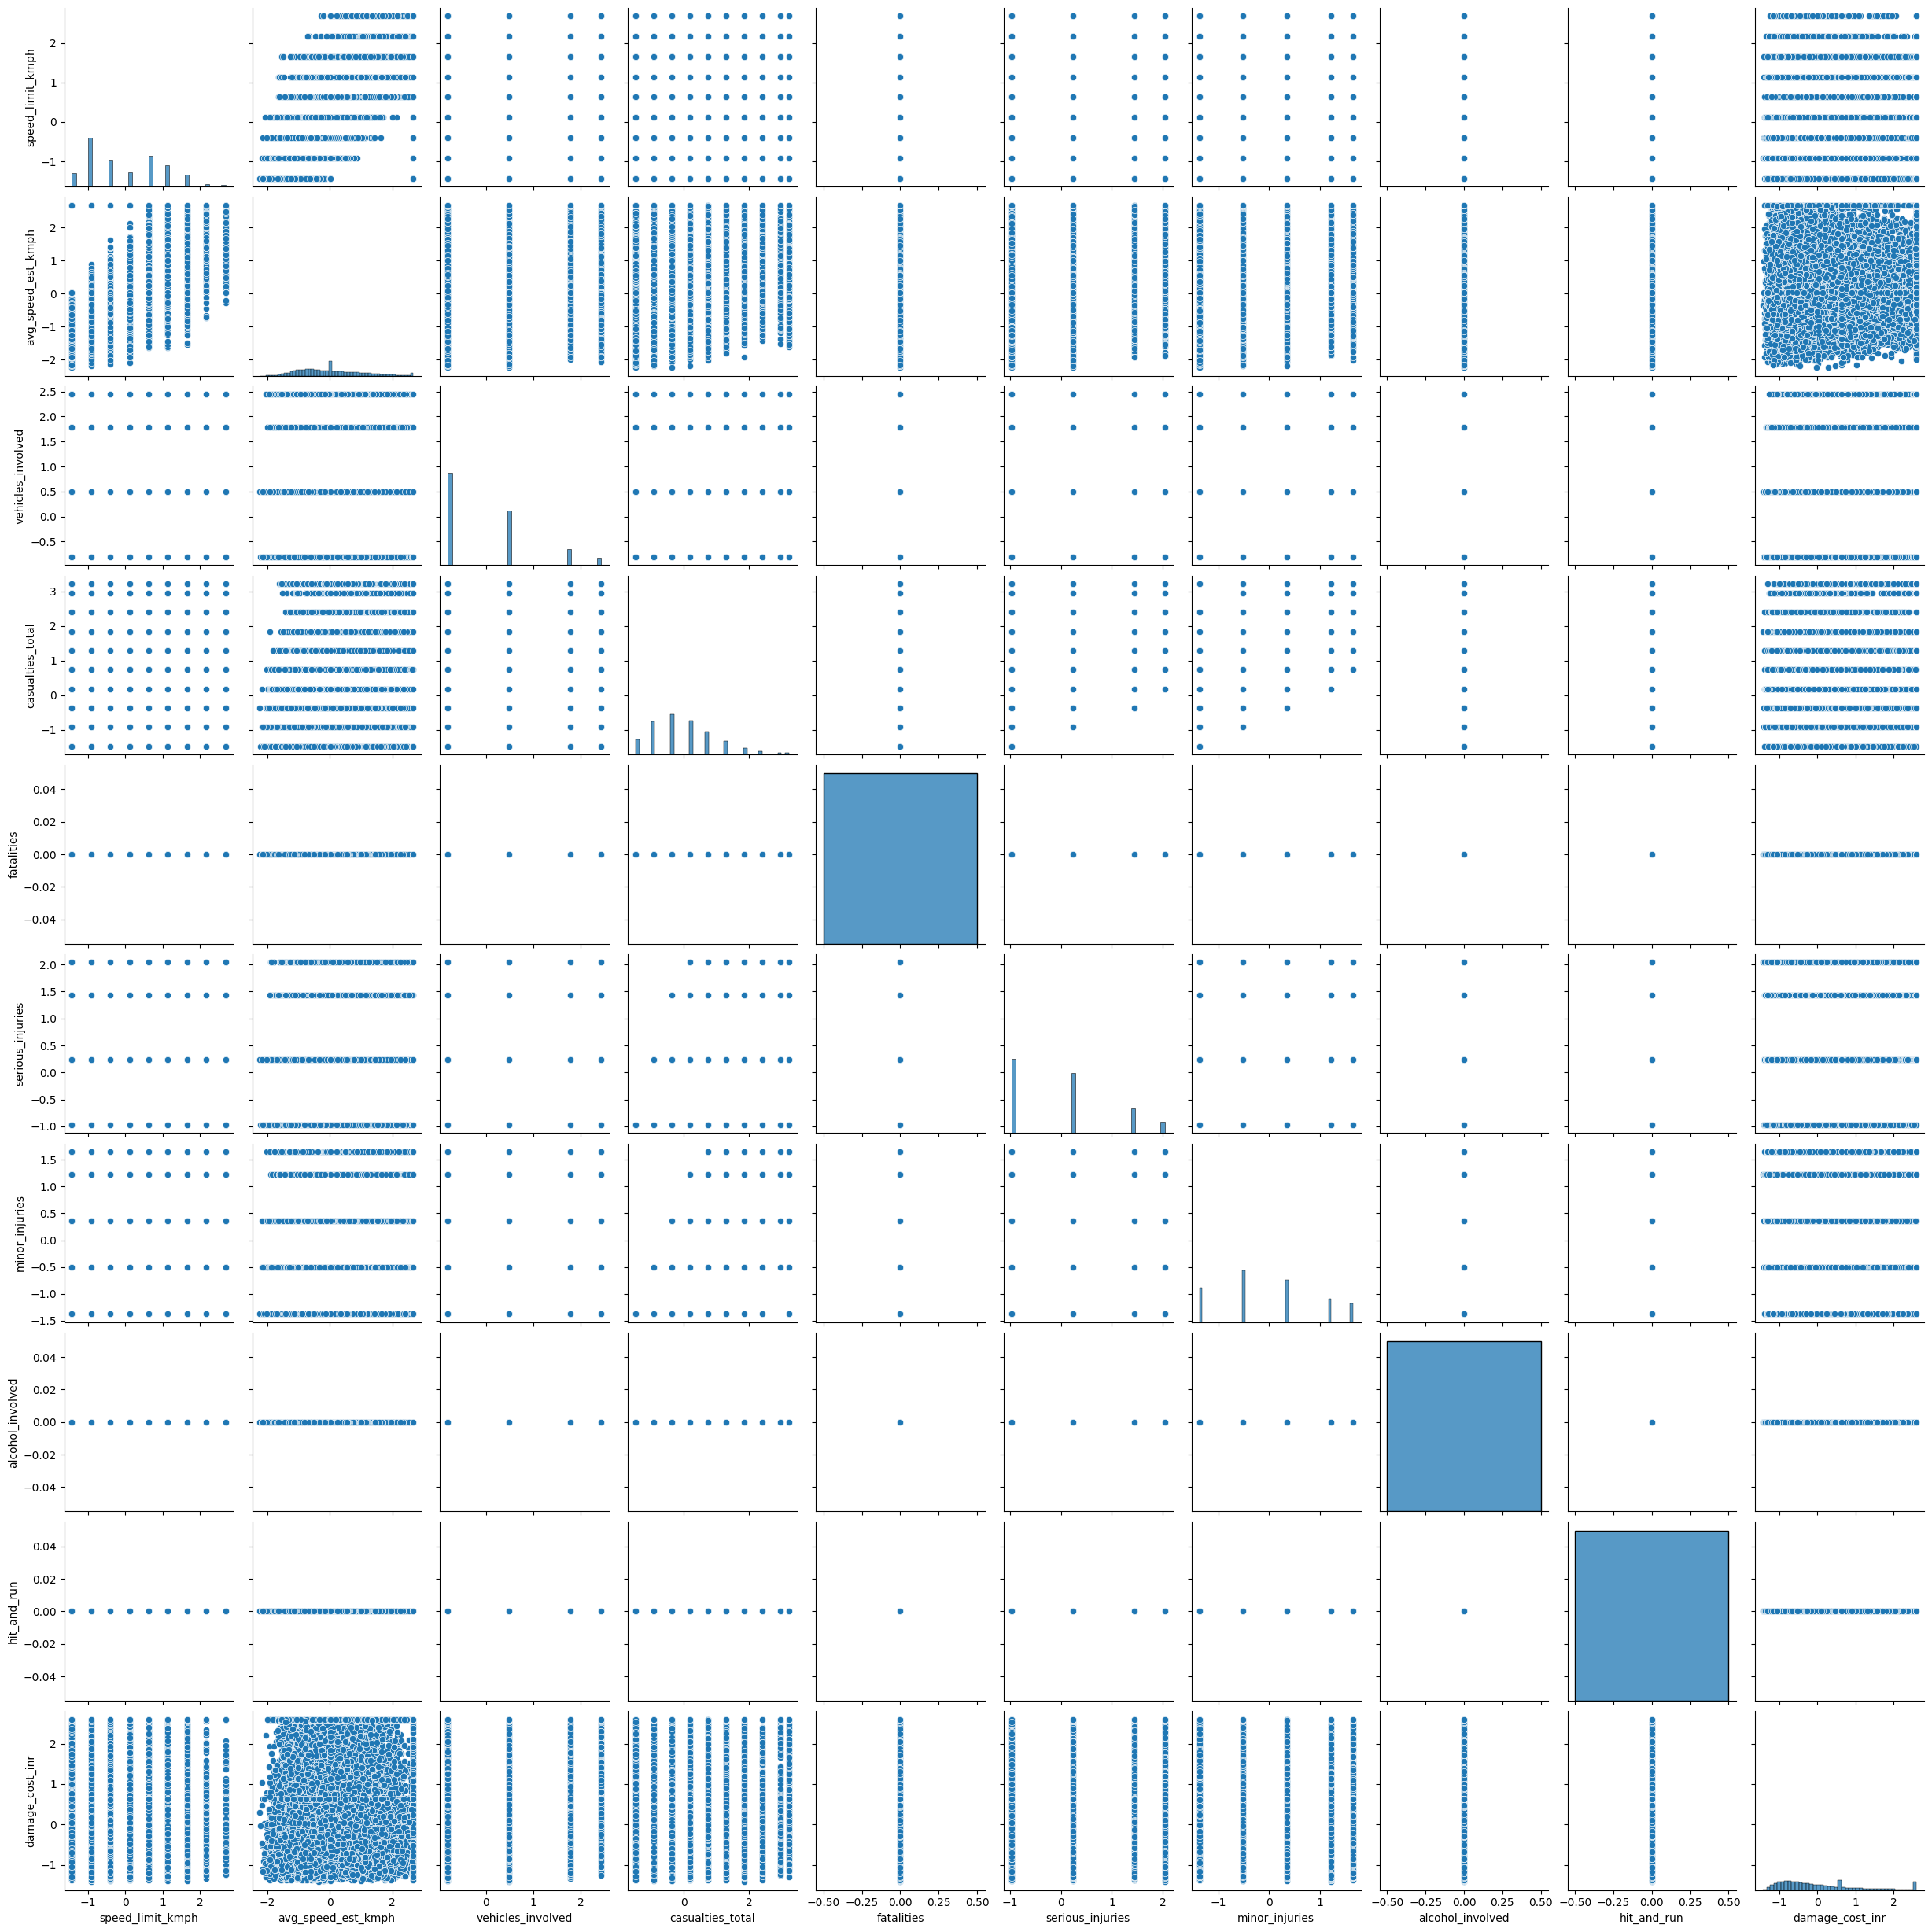

In [24]:
sns.pairplot(df[num_cols])
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Correlation Heatmap**  
A heatmap using **sns.heatmap()** was plotted.

**Insights:**
* Strong positive correlation between casualties and injuries.
* Speed limit shows moderate correlation with estimated speed.
* Damage cost correlates with injury severity.

**Why heatmap:**
* Summarizes correlation strength and direction clearly.

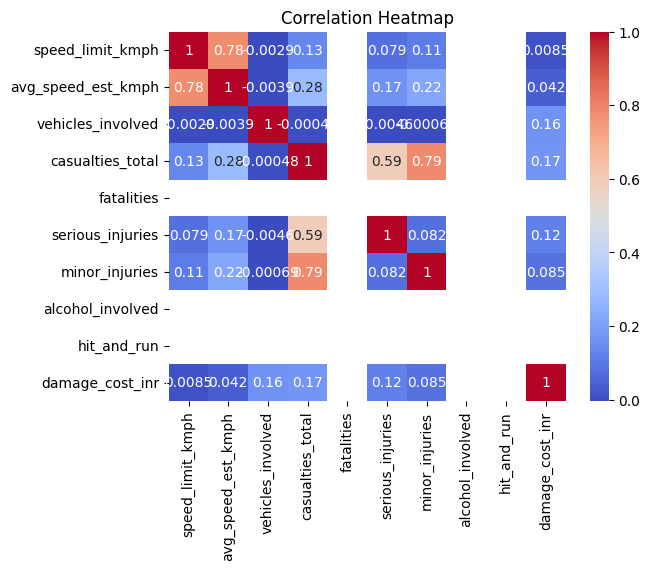

In [25]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **10. Trend Visualization**

A line plot was generated for a numerical variable across index order.

**Purpose:**
* To observe overall variability and fluctuation patterns.
* Useful for spotting volatility in accident-related measures.

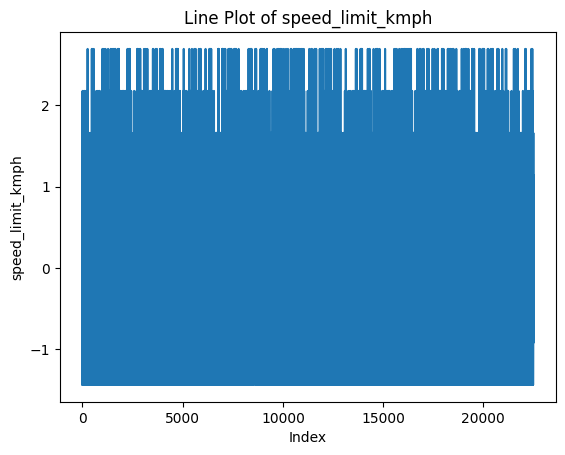

In [26]:
plt.plot(df[num_cols[0]])
plt.title(f"Line Plot of {num_cols[0]}")
plt.xlabel("Index")
plt.ylabel(num_cols[0])
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **11. Probability and Distribution Analysis**

**Binomial Distribution**  
A binomial distribution was plotted to demonstrate discrete probability concepts.

**Purpose:**
* To model event occurrence probability.
* Illustrates probability mass function behavior.

In [27]:
from itertools import permutations, combinations

list(permutations([1,2,3], 2))
list(combinations([1,2,3], 2))

[(1, 2), (1, 3), (2, 3)]

In [28]:
P_A = 0.6
P_B = 0.3
P_A_and_B = P_A * P_B
P_A_or_B = P_A + P_B - P_A_and_B

In [29]:
values = np.array([0,1])
probs = np.array([0.4,0.6])
np.sum(values * probs)

np.float64(0.6)

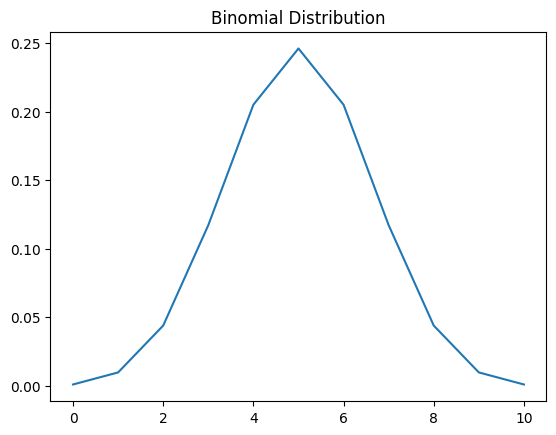

In [30]:
x = np.arange(0,11)
plt.plot(x, stats.binom.pmf(x, 10, 0.5))
plt.title("Binomial Distribution")
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Normal Distribution**  
The normal distribution curve was plotted.

**Purpose:**
* To demonstrate continuous probability distribution.
* Serves as a reference for CLT and hypothesis testing.

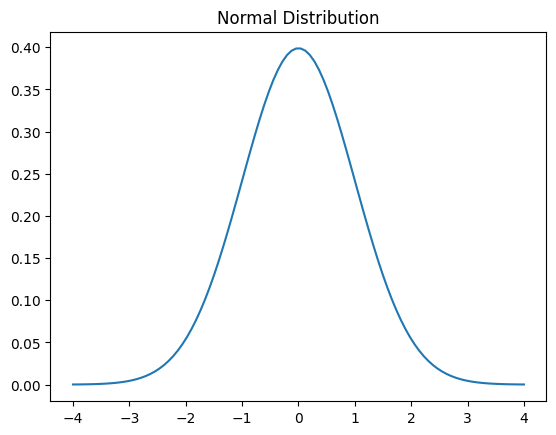

In [31]:
x = np.linspace(-4,4,100)
plt.plot(x, stats.norm.pdf(x))
plt.title("Normal Distribution")
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **12. Central Limit Theorem Demonstration**

Random samples were drawn repeatedly, and their means were plotted.

**Insight:**
* The sampling distribution of the mean appears approximately normal.
* Confirms the Central Limit Theorem despite original data being skewed.

**Importance:**
* Justifies use of parametric tests such as t-tests.

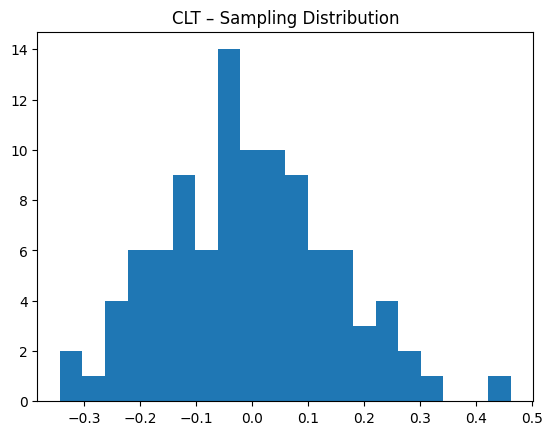

In [32]:
sample_means = []

for i in range(100):
    sample = df[num_cols[0]].sample(50, replace=True)
    sample_means.append(sample.mean())

plt.hist(sample_means, bins=20)
plt.title("CLT – Sampling Distribution")
plt.show()

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **13. Confidence Interval Estimation**

A 95% confidence interval was computed for the mean.

**Interpretation:**
* We are 95% confident that the true population mean lies within this interval.
* Provides an uncertainty-aware estimate rather than a single value.

In [33]:
mean = df[num_cols[0]].mean()
std = df[num_cols[0]].std()
n = len(df)

stats.norm.interval(0.95, mean, std/np.sqrt(n))

(np.float64(-0.013066716938314186), np.float64(0.013066716938314415))

In [34]:
stats.zscore(df[num_cols])

array([[-1.43579615, -1.9015961 ,  0.49093896, ...,         nan,
                nan, -0.78117634],
       [-0.92018825, -0.59033319, -0.8074597 , ...,         nan,
                nan,  0.16574998],
       [-0.92018825,  0.02053936,  0.49093896, ...,         nan,
                nan, -0.96356029],
       ...,
       [-0.92018825, -1.13789353, -0.8074597 , ...,         nan,
                nan, -0.66886804],
       [ 0.62663548, -0.81127859, -0.8074597 , ...,         nan,
                nan, -0.50950752],
       [-0.40458034, -0.15804872,  0.49093896, ...,         nan,
                nan,  0.10672592]], shape=(22500, 10))

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **14. Hypothesis Testing**

**One-Sample t-Test**  
Tested whether the mean differs from a hypothesized value.

**Result:**
* High p-value → fail to reject null hypothesis.
* Indicates no statistically significant difference from the assumed mean.

In [35]:
P_A = 0.3
P_B_given_A = 0.7
P_B = 0.5

(P_B_given_A * P_A) / P_B

0.42

In [36]:
t_stat, p_val = stats.ttest_1samp(df[num_cols[0]], 0)
t_stat, p_val

(np.float64(1.7194752087055165e-14), np.float64(0.9999999999999862))

In [37]:
alpha = 0.05
"Reject H0" if p_val < alpha else "Fail to Reject H0"

'Fail to Reject H0'

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Two-Sample t-Test**   
Compared two randomly split groups.  

**Insight:**  
* No significant difference observed.  
* Suggests similar behavior across randomly divided samples.  

In [42]:
g1, g2 = np.array_split(df[num_cols[0]].sample(frac=1).values, 2)
stats.ttest_ind(g1, g2)

TtestResult(statistic=np.float64(-1.213383047434025), pvalue=np.float64(0.22499614336920504), df=np.float64(22498.0))

<div style="text-align: center;">

# -------------------------------------------------

</div>

**Chi-Square Test**  
Tested association between two categorical variables.

**Interpretation:**
* High p-value indicates no strong dependency.
* Suggests categorical features may be independent.

In [43]:
cont_table = pd.crosstab(df[cat_cols[0]], df[cat_cols[1]])
stats.chi2_contingency(cont_table)

Chi2ContingencyResult(statistic=np.float64(63135000.00000007), pvalue=np.float64(0.4013817897089748), dof=63132194, expected_freq=array([[2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04],
       [2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04],
       [2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04],
       ...,
       [2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04],
       [2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04],
       [2.66666667e-04, 3.11111111e-04, 8.88888889e-05, ...,
        4.00000000e-04, 3.55555556e-04, 4.00000000e-04]],
      shape=(22500, 2807)))

<div style="text-align: center;">

# -------------------------------------------------

</div>

**ANOVA**  
Compared means across groups.

**Result:**
* No statistically significant difference detected.

In [44]:
stats.f_oneway(g1, g2)

F_onewayResult(statistic=np.float64(1.472298419800281), pvalue=np.float64(0.22499614337018475))

<div style="text-align: center;">

# -------------------------------------------------

</div>

**A/B Testing Simulation**  
Simulated control vs variant comparison.

**Insight:**
* Statistically significant difference observed.
* Demonstrates real-world experimentation logic.

In [45]:
control = np.random.normal(50,5,100)
variant = np.random.normal(52,5,100)
stats.ttest_ind(control, variant)

TtestResult(statistic=np.float64(-2.112401598724526), pvalue=np.float64(0.03590537181891341), df=np.float64(198.0))

<div style="text-align: center;">

# -------------------------------------------------

</div>

### **15. Final Conclusion**

This project successfully applied exploratory data analysis, visualization techniques, and statistical inference to a large-scale road accident dataset. The analysis revealed key insights into accident severity, speed behavior, and injury patterns. Visualizations enabled intuitive understanding, while inferential statistics provided mathematical validation.

The results highlight that while most accidents are minor, extreme cases significantly impact fatalities and economic damage. Such findings can support targeted road safety interventions, policy planning, and further predictive modeling.

<div style="text-align: center;">

# -------------------------------------------------

</div>